# Notebook 05: Final Model Comparison and Analysis

Here, we bring together the results from our three distinct Mixture Models:
1. **Gaussian Mixture Model (GMM):** Trained on PCA-compressed data.
2. **Laplacian Mixture Model (LMM):** Trained on PCA-compressed data.
3. **Bernoulli Mixture Model (BMM):** Trained on uncompressed, binarized pixel data.

We will compare their clustering performance using **Accuracy (Purity)**, **Adjusted Rand Index (ARI)**, and **Normalized Mutual Information (NMI)**. 

In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def load_metrics(filepath, name):
    try:
        with open(filepath, 'rb') as f:
            return pickle.load(f)
    except FileNotFoundError:
        print(f"Warning: {filepath} not found.")
        return {'Accuracy': 0.0, 'ARI': 0.0, 'NMI': 0.0}

# Load metrics
gmm_metrics = load_metrics('data/gmm_metrics.pkl', 'GMM')
lmm_metrics = load_metrics('data/laplacian_metrics.pkl', 'LMM')
bmm_metrics = load_metrics('data/bmm_metrics.pkl', 'BMM')

# Create a Pandas DataFrame for easy viewing
df_metrics = pd.DataFrame([gmm_metrics, lmm_metrics, bmm_metrics], index=['Gaussian (PCA)', 'Laplacian (PCA)', 'Bernoulli (Binary)'])

print("--- Final Clustering Metrics (K=25) ---")
display(df_metrics.round(4))

--- Final Clustering Metrics (K=25) ---


,Accuracy,ARI,NMI
Gaussian (PCA),0.7689,0.3592,0.6206
Laplacian (PCA),0.7071,0.2886,0.5385
Bernoulli (Binary),0.7595,0.3285,0.5754


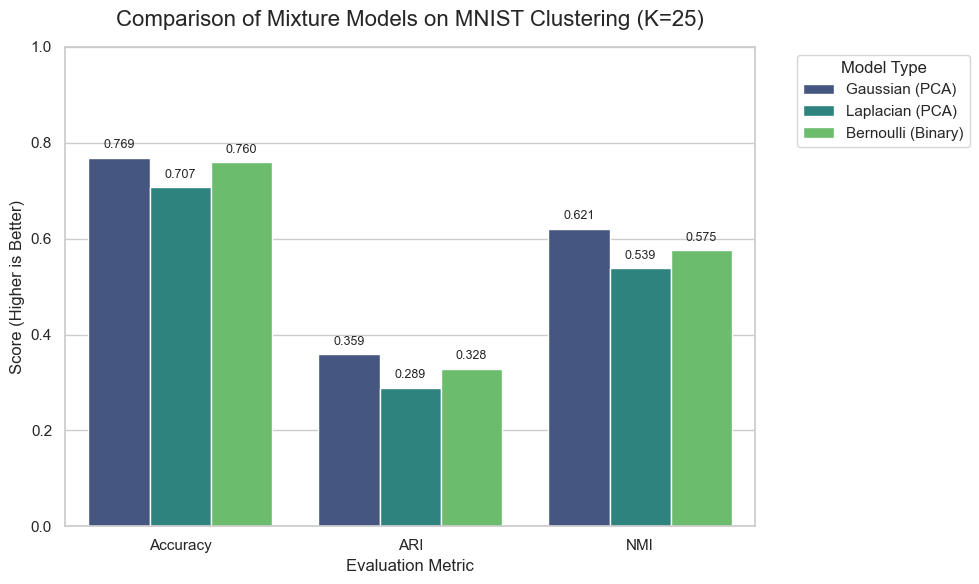

In [2]:
# Set up the bar chart
sns.set_theme(style="whitegrid")
df_melted = df_metrics.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='Metric', y='Score', hue='index', data=df_melted, palette='viridis')

plt.title('Comparison of Mixture Models on MNIST Clustering (K=25)', fontsize=16, pad=15)
plt.ylabel('Score (Higher is Better)', fontsize=12)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylim(0, 1.0) # Metrics are naturally bounded between 0 and 1
plt.legend(title='Model Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add text labels on top of the bars
for p in barplot.patches:
    if p.get_height() > 0:
        barplot.annotate(format(p.get_height(), '.3f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha = 'center', va = 'center', 
                         xytext = (0, 9), 
                         textcoords = 'offset points',
                         fontsize=9)

plt.tight_layout()
plt.show()